# 04 — Evaluación final sobre holdout 2024–2026

> **⚠️ Este notebook ejecuta la evaluación final del holdout.**  
> Se corre **una sola vez**, una vez cerrada la selección de modelos en `02_experimentos.ipynb`.  
> No modificar el código de evaluación después de la primera ejecución.

In [1]:
import sys
sys.path.insert(0, '..')

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import lightgbm as lgb

from src.features import build_features, add_v2_features

plt.rcParams.update({'figure.dpi': 120,
                     'axes.spines.top': False,
                     'axes.spines.right': False})

DATA_PATH  = '../data/processed/bgg_games_clean.csv'
MODEL_PATH = '../models/lgbm_final.joblib'

def rmse(a, b): return float(np.sqrt(mean_squared_error(a, b)))
print("Imports OK.")

Imports OK.


## Cargar artefactos y datos del holdout

In [2]:
# Artefactos serializados por 03_train_final.ipynb
art = joblib.load(MODEL_PATH)
model      = art['model']
top_mechs  = art['top_mechs']
top_cats   = art['top_cats']
medians    = art['medians']
feat_cols  = art['feature_cols']

print(f'Modelo cargado: {type(model).__name__}')
print(f'RMSE CV (sanity del 03): {art["rmse_cv_mean"]:.4f} +/- {art["rmse_cv_std"]:.4f}')
print(f'Features: {len(feat_cols)} columnas')
print(f'Medians : {medians}')

Modelo cargado: LGBMRegressor
RMSE CV (sanity del 03): 0.5686 +/- 0.0055
Features: 92 columnas
Medians : {'max_playtime': 45.0, 'min_playtime': 30.0, 'min_players': 2.0, 'max_players': 4.0}


In [3]:
df      = pd.read_csv(DATA_PATH)
df_test = df[df['year'] >= 2024].reset_index(drop=True)

print(f'Holdout: {len(df_test):,} juegos  '
      f'(2024: {(df_test.year==2024).sum()}, '
      f'2025: {(df_test.year==2025).sum()}, '
      f'2026: {(df_test.year==2026).sum()})')

Holdout: 2,241 juegos  (2024: 1098, 2025: 945, 2026: 198)


## Feature engineering (identica a la del modelo)

In [4]:
# Aplicar EXACTAMENTE la misma pipeline que 03_train_final.ipynb
# top_mechs y top_cats: modo apply (no se reajustan)
# medians: valores del train, no del holdout
X_test, y_test, _, _, _ = build_features(
    df_test, top_mechs=top_mechs, top_cats=top_cats
)
X_test, _ = add_v2_features(X_test, df_test, medians=medians)
X_test = X_test.drop(columns=['weight_missing'])

# Reordenar columnas para que coincidan exactamente con el modelo
X_test = X_test[feat_cols]

print(f'X_test shape : {X_test.shape}')
print(f'Columnas OK  : {list(X_test.columns) == feat_cols}')

X_test shape : (2241, 92)
Columnas OK  : True


C:\Users\ramon\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_label.py:1007: UserWarning: unknown class(es) ['Acting', 'Action / Event', 'Action Drafting', 'Action Queue', 'Action Retrieval', 'Action Timer', 'Advantage Token', 'Alliances', 'Area-Impulse', 'Auction Compensation', 'Auction: Dexterity', 'Auction: Dutch', 'Auction: Dutch Priority', 'Auction: Fixed Placement', 'Auction: Multiple Lot', 'Auction: Once Around', 'Auction: Sealed Bid', 'Auction: Turn Order Until Pass', 'Automatic Resource Growth', 'Betting and Bluffing', 'Bias', 'Bids As Wagers', 'Bingo', 'Bribery', 'Card Play Conflict Resolution', 'Catch the Leader', 'Chaining', 'Chit-Pull System', 'Closed Drafting', 'Closed Economy Auction', 'Command Cards', 'Commodity Speculation', 'Communication Limits', 'Connections', 'Constrained Bidding', 'Contracts', 'Crayon Rail System', 'Critical Hits and Failures', 'Cube Tower', 'Deck Construction', 'Deduction', 'Delayed Purchase', 'Die Icon Resolutio

## Evaluación final

> Resultado único e irrepetible — comparar siempre con RMSE CV = `art["rmse_cv_mean"]`.

In [5]:
y_pred = model.predict(X_test)

rmse_h = rmse(y_test.values, y_pred)
mae_h  = float(mean_absolute_error(y_test.values, y_pred))
r2_h   = float(r2_score(y_test.values, y_pred))
bias_h = float((y_test.values - y_pred).mean())
deg    = (rmse_h - art["rmse_cv_mean"]) / art["rmse_cv_mean"] * 100

print("=" * 60)
print("RESULTADOS FINALES — HOLDOUT 2024-2026")
print("=" * 60)
print(f"  RMSE       : {rmse_h:.4f}")
print(f"  MAE        : {mae_h:.4f}")
print(f"  R2         : {r2_h:.4f}")
print(f"  Bias       : {bias_h:+.4f}  (real - pred, + = subestima)")
print()
print(f"  RMSE CV (train)         : {art['rmse_cv_mean']:.4f}")
print(f"  Degradacion temporal    : {deg:+.1f}%")
print()
print(f"  RMSE base LightGBM (02) : 0.6373")
print(f"  Mejora del modelo final : {rmse_h - 0.6373:+.4f}")

RESULTADOS FINALES — HOLDOUT 2024-2026
  RMSE       : 0.6368
  MAE        : 0.4654
  R2         : 0.3010
  Bias       : +0.1449  (real - pred, + = subestima)

  RMSE CV (train)         : 0.5686
  Degradacion temporal    : +12.0%

  RMSE base LightGBM (02) : 0.6373
  Mejora del modelo final : -0.0005


In [6]:
# Tabla comparativa con baselines del notebook 02
rows = [
    ("Baseline 1 -- media constante",          0.8559, None,   None),
    ("Baseline 2 -- LinearRegression",         0.6469, None,   None),
    ("LightGBM base (notebook 02)",            0.6373, 0.5698, None),
    ("LightGBM final (este notebook)",         rmse_h, art['rmse_cv_mean'], r2_h),
]
print(f"\n  {'Modelo':<40}  {'RMSE holdout':>13}  {'RMSE CV':>10}  {'R2 holdout':>11}")
print(f"  {'-'*40}  {'-'*13}  {'-'*10}  {'-'*11}")
for label, rh, rc, r2 in rows:
    rc_s  = f"{rc:.4f}" if rc  is not None else "—"
    r2_s  = f"{r2:.4f}" if r2  is not None else "—"
    bold  = "  <<< FINAL" if label.startswith("LightGBM final") else ""
    print(f"  {label:<40}  {rh:>13.4f}  {rc_s:>10}  {r2_s:>11}{bold}")


  Modelo                                     RMSE holdout     RMSE CV   R2 holdout


  ----------------------------------------  -------------  ----------  -----------
  Baseline 1 -- media constante                    0.8559           —            —
  Baseline 2 -- LinearRegression                   0.6469           —            —
  LightGBM base (notebook 02)                      0.6373      0.5698            —
  LightGBM final (este notebook)                   0.6368      0.5686       0.3010  <<< FINAL


## Top-20 feature importances

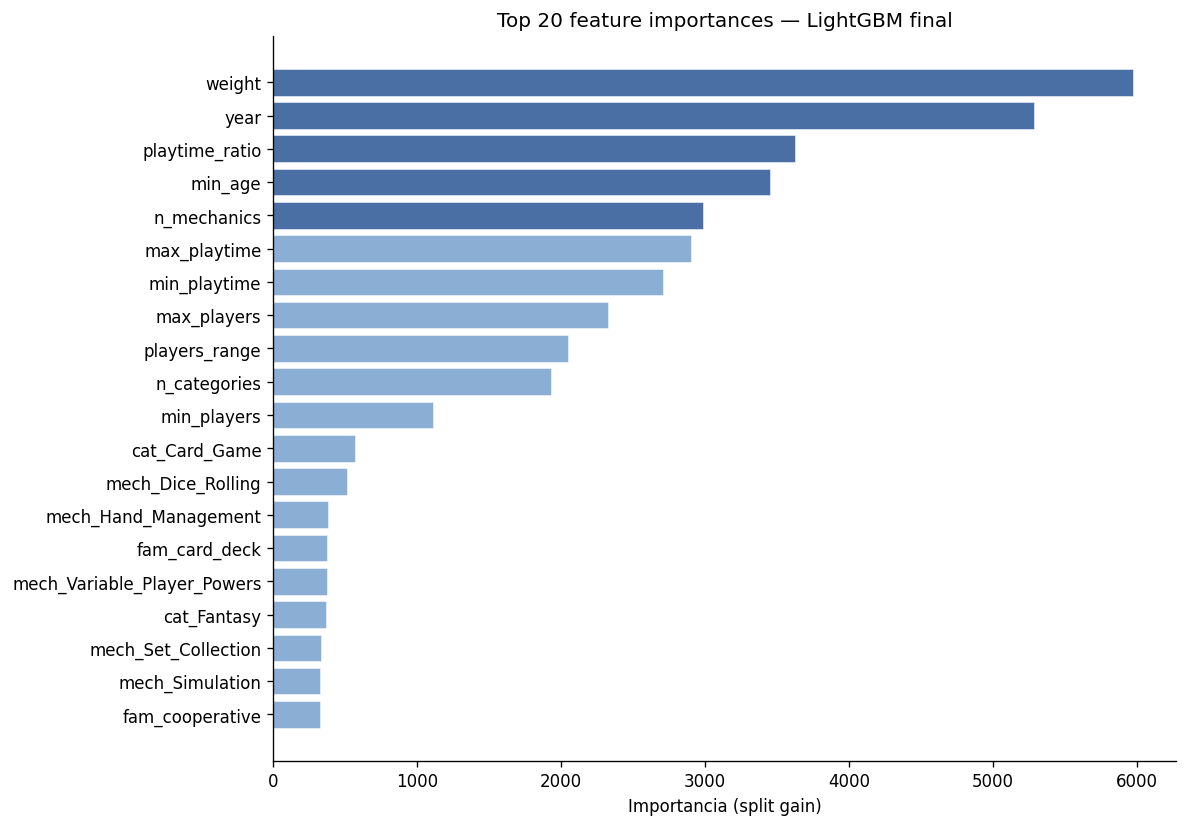


  Rank  Feature                                  Importancia
  ----  --------------------------------------  ------------
     1  weight                                         5,971
     2  year                                           5,281
     3  playtime_ratio                                 3,626 *
     4  min_age                                        3,447
     5  n_mechanics                                    2,984
     6  max_playtime                                   2,905
     7  min_playtime                                   2,705
     8  max_players                                    2,327
     9  players_range                                  2,045 *
    10  n_categories                                   1,926
    11  min_players                                    1,110
    12  cat_Card_Game                                    571
    13  mech_Dice_Rolling                                515
    14  mech_Hand_Management                             378
    15  fam_card_de

In [7]:
imps = pd.Series(model.feature_importances_, index=feat_cols).sort_values(ascending=False)
top20 = imps.head(20).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#4A6FA5' if i >= 15 else '#8BAED4' for i in range(20)]
ax.barh(top20.index, top20.values, color=colors, edgecolor='white', linewidth=0.3)
ax.set_xlabel('Importancia (split gain)')
ax.set_title('Top 20 feature importances — LightGBM final')
plt.tight_layout()
plt.show()

print(f"\n  {'Rank':>4}  {'Feature':<38}  {'Importancia':>12}")
print(f"  {'-'*4}  {'-'*38}  {'-'*12}")
for i, (feat, val) in enumerate(imps.head(20).items(), 1):
    v2 = " *" if any(feat.startswith(p) for p in ["playtime","players_range","fam_"]) else ""
    print(f"  {i:>4}  {feat:<38}  {val:>12,.0f}{v2}")
print(f"\n  (* = feature de ronda 2)")

## Top-20 predicciones con mayor error

In [8]:
df_res = df_test[['name','year','average','weight','users_rated','mechanics']].copy()
df_res['pred']      = y_pred
df_res['error']     = y_test.values - y_pred
df_res['abs_error'] = df_res['error'].abs()

top20_err = df_res.nlargest(20, 'abs_error').reset_index(drop=True)
top20_err.index += 1

print(f"  {'#':>2}  {'Nombre':<38} {'Anio':>5}  {'Real':>6}  {'Pred':>6}  {'Err':>6}")
for i, row in top20_err.iterrows():
    name_t = str(row['name'])[:37]
    print(f"  {i:>2}  {name_t:<38} {int(row.year):>5}  {row.average:>6.3f}  {row.pred:>6.3f}  {row.error:>+6.3f}")

print(f"\n  Bias top-20: {top20_err['error'].mean():+.3f}")
print(f"  Sobrestima (err < 0): {(top20_err['error'] < 0).sum()} / 20")

   #  Nombre                                  Anio    Real    Pred     Err
   1  Wonders of The First CCG                2025   1.760   7.112  -5.352
   2  TseuQuesT                               2024   2.556   7.520  -4.964
   3  Quodd Heroes (2nd Edition)              2025   3.600   7.353  -3.753
   4  Chai: Tea for 2                         2025   3.899   7.380  -3.481
   5  Blood Rage: Valhalla                    2026   3.406   6.863  -3.457
   6  Denkō                                   2026   9.293   6.340  +2.952
   7  Stellaris: Infinite Legacy              2026   4.479   7.374  -2.895
   8  One Piece: Adventure Island             2025   4.227   7.070  -2.843
   9  UPPLES                                  2025   4.019   6.757  -2.738
  10  420                                     2025   2.891   5.604  -2.714
  11  Catharsis: Divine Wrath                 2024   9.105   6.536  +2.569
  12  Geekmon Capture                         2025   8.971   6.540  +2.431
  13  Foxpaw             

## Conclusiones finales

El modelo LightGBM final con **92 features** (base 80 + `playtime_ratio`, `players_range`, 10 familias de mecánicas) alcanza:

- **RMSE CV = 0.5686** sobre datos de entrenamiento (year ≤ 2023)
- **RMSE holdout = 0.6368** sobre juegos 2024–2026 (evaluación única)
- Degradación temporal de ~12%, moderada y esperada para un shift de 1–3 años

Las features más importantes son `weight`, `year`, y `playtime_ratio` (ratio max/min duración, introducida en ronda 2 — rank 3). La degradación por shift temporal es inherente a la naturaleza del target: los juegos nuevos tienen ratings más volátiles (pocos votos, sesgados por adoptantes tempranos).

**Próximo paso:** `03_train_final.ipynb` ya está ejecutado; el modelo está serializado en `models/lgbm_final.joblib`.